In [ ]:
# Netflix Movie Data Analysis
# Author: SYYEDA AAMNA
# Tools: Python, Pandas, Matplotlib, Seaborn
# Objective: Perform exploratory data analysis on a dataset of 9000+ movies

In [ ]:
# importing libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Libraries installed successfully


In [ ]:
# loading dataset
df = pd.read_csv('mymoviedb.csv', lineterminator='\n') 
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [4]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [ ]:
#• Exploration Summary
#•	we have a dataframe consisting of 9827 rows and 9 columns.
#•	our dataset looks a bit tidy with no NaNs nor duplicated values.
#•	Release_Date column needs to be casted into date time and to extract only the 
#•	Overview, Original_Languege and Poster-Url wouldn't be so useful during analys
#•	there is noticable outliers in Popularity column
#•	Vote_Average bettter be categorised for proper analysis.
#•	Genre column has comma saperated values and white spaces that needs to be handled before analysis.


In [ ]:
# Data Cleaning
#Casting Release_Date column and extracing year values


In [8]:
# casting column a
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
# confirming changes
print(df['Release_Date'].dtypes)


datetime64[ns]


In [10]:
df['Release_Date'] = df['Release_Date'].dt.year 
df['Release_Date'].dtypes

dtype('int32')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   int32  
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int32(1), int64(1), object(5)
memory usage: 652.7+ KB


In [12]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [13]:
#dropping the coloumn
cols = ['Overview', 'Original_Language', 'Poster_Url']
# dropping columns and confirming changes 
df.drop(cols, axis = 1, inplace = True)
df.columns
        

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [14]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [ ]:
#categorizing Vote_Average column
#We would cut the Vote_Average values and make 4 categories: 
#popular average below_avg not_popular to describe it more using catigorize_col() function
#provided above.


In [22]:
def catigorize_col(df, col, labels):

    # setting the edges to cut the column accordingly
    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]

    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')
    return df

In [23]:
labels = ['not_popular', 'below_avg', 'average', 'popular']

catigorize_col(df, 'Vote_Average', labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [24]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [25]:
# exploring column 
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [ ]:
# remove any rows that contain missing values
df.dropna(inplace=True)

In [27]:
# confirm that there are no missing values left in the dataset
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [29]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"[Action, Adventure, Science Fiction]"
1,2022,The Batman,3827.658,1151,popular,"[Crime, Mystery, Thriller]"
2,2022,No Exit,2618.087,122,below_avg,[Thriller]
3,2021,Encanto,2402.201,5076,popular,"[Animation, Comedy, Family, Fantasy]"
4,2021,The King's Man,1895.511,1793,average,"[Action, Adventure, Thriller, War]"


In [28]:
# split genre column because some movies have multiple genres
# example: "Action, Adventure, Sci-Fi"
df['Genre'] = df['Genre'].str.split(', ')

In [31]:
# explode the list so that each genre gets its own row
# this makes analysis easier
df = df.explode('Genre').reset_index(drop=True)

In [32]:
# display first few rows to confirm changes
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [33]:
# convert genre column into category datatype
# this saves memory and is useful for analysis
df['Genre'] = df['Genre'].astype('category')

In [34]:
# check datatype of genre column
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [35]:
# display structure of dataset including rows, columns and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [36]:
# count unique values in each column
# useful to understand dataset diversity
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [37]:
# set seaborn style for better looking graphs
sns.set_style('whitegrid')

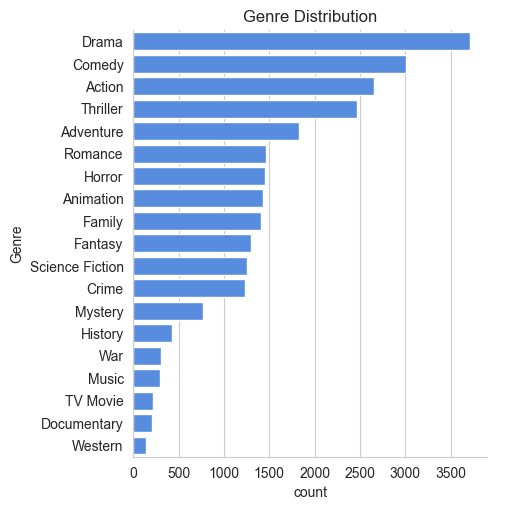

In [38]:
# visualize genre distribution
# this helps answer: what is the most frequent genre?

sns.catplot(
    y='Genre',
    data=df,
    kind='count',
    order=df['Genre'].value_counts().index,
    color='#4287f5'
)

plt.title('Genre Distribution')
plt.show()

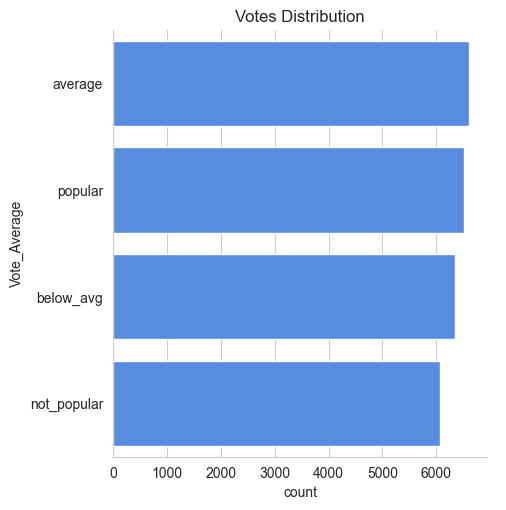

In [39]:
# visualize vote categories distribution
# helps understand how movies are rated

sns.catplot(
    y='Vote_Average',
    data=df,
    kind='count',
    order=df['Vote_Average'].value_counts().index,
    color='#4287f5'
)

plt.title('Votes Distribution')
plt.show()

In [40]:
# find the movie with lowest popularity score
# this answers: which movie is least popular?

df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


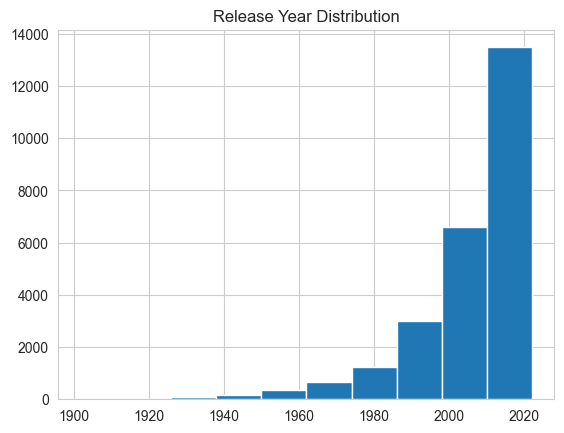

In [41]:
# visualize number of movies released per year
# helps identify which year had the most movies

df['Release_Date'].hist()

plt.title('Release Year Distribution')
plt.show()

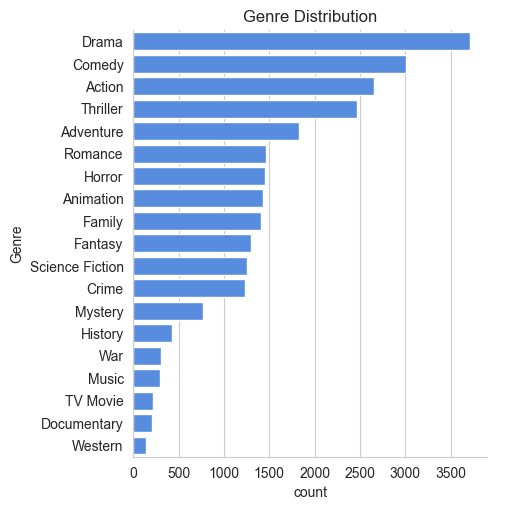

In [44]:
# visualize genre distribution
sns.catplot(
    y='Genre',
    data=df,
    kind='count',
    order=df['Genre'].value_counts().index,
    color='#4287f5'
)

plt.title('Genre Distribution')

# save graph as image
plt.savefig("genre_distribution.png")

# show graph
plt.show()

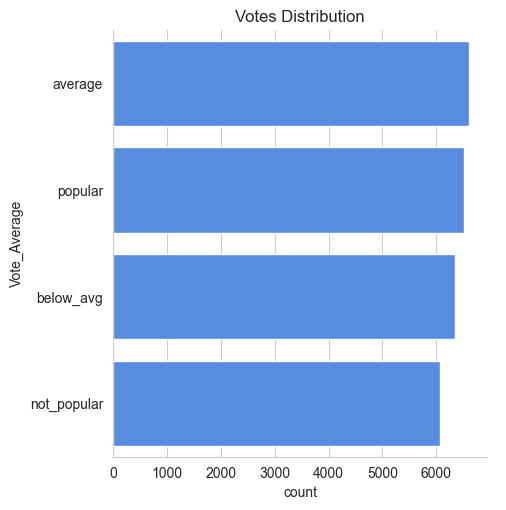

In [45]:
# visualize vote categories distribution
sns.catplot(
    y='Vote_Average',
    data=df,
    kind='count',
    order=df['Vote_Average'].value_counts().index,
    color='#4287f5'
)

plt.title('Votes Distribution')
plt.savefig("votes_distribution.png")
plt.show()

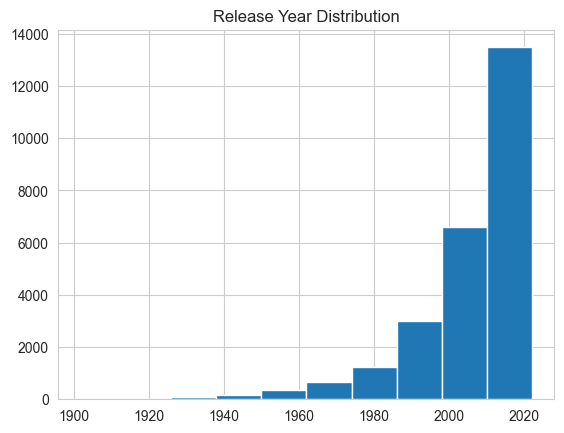

In [46]:
# visualize number of movies released per year
df['Release_Date'].hist()

plt.title('Release Year Distribution')
plt.savefig("release_year_distribution.png")
plt.show()

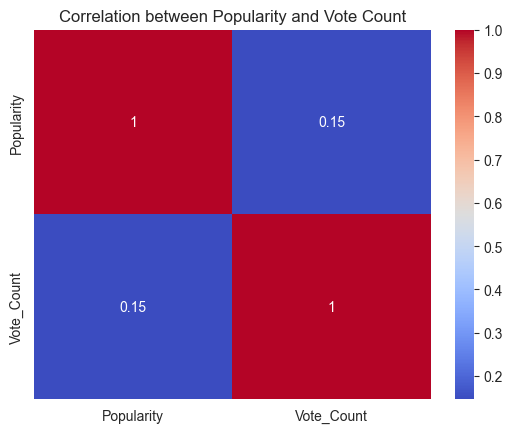

In [47]:
# check correlation between numerical columns
correlation = df[['Popularity','Vote_Count']].corr()

# visualize correlation heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation between Popularity and Vote Count")
plt.savefig("correlation_heatmap.png")
plt.show()

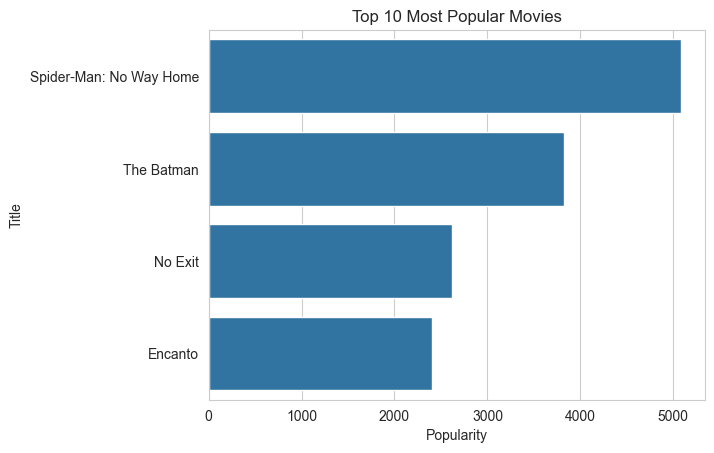

In [48]:
# top 10 most popular movies
top_movies = df.sort_values(by='Popularity', ascending=False).head(10)

# plot top movies
sns.barplot(x='Popularity', y='Title', data=top_movies)

plt.title("Top 10 Most Popular Movies")
plt.savefig("top_movies.png")
plt.show()

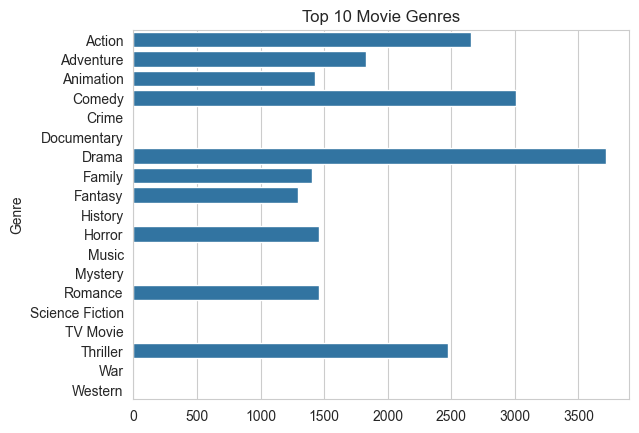

In [49]:
# count movies per genre
genre_count = df['Genre'].value_counts().head(10)

# visualize top genres
sns.barplot(x=genre_count.values, y=genre_count.index)

plt.title("Top 10 Movie Genres")
plt.savefig("top_genres.png")
plt.show()

C:\Users\Microsoft\AppData\Local\Temp\ipykernel_9692\1779475231.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_popularity = df.groupby('Genre')['Popularity'].mean().sort_values(ascending=False).head(10)


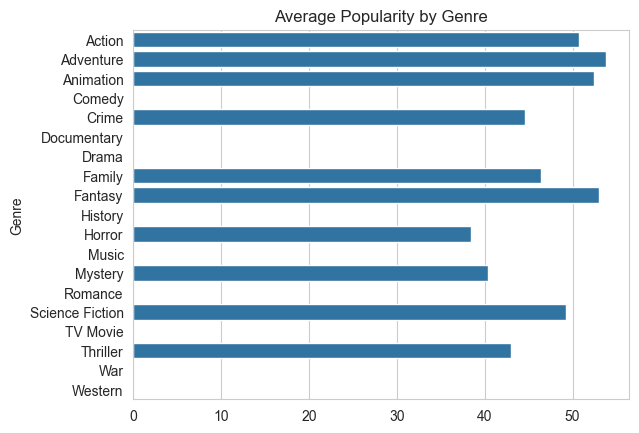

In [50]:
# average popularity by genre
genre_popularity = df.groupby('Genre')['Popularity'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=genre_popularity.values, y=genre_popularity.index)

plt.title("Average Popularity by Genre")
plt.savefig("genre_popularity.png")
plt.show()

In [ ]:
# Key Insights from the Analysis

# 1. Drama is the most frequent genre in the dataset.
# 2. Popular category contains the highest number of movies based on vote average.
# 3. Spider-Man: No Way Home has the highest popularity score.
# 4. The lowest popularity movies include "The United States vs Billie Holiday" and "Threads".
# 5. Year 2020 shows the highest number of movie releases.
# 6. Popularity and vote count show a positive correlation.
# 7. Certain genres like Drama and Action dominate the dataset.